In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns



In [15]:
#1. Зниження розмірності і візуалізація даних
#Застосуйте методи зниження розмірності sklearn.decomposition.PCA і sklearn.manifold.TSNE для візуалізації даних,
# з якими ви працювали в лабораторній № 1 (знижуючи розмірність до двох). Візуалізуйте результат.

In [22]:

wine = fetch_ucirepo(id=109)
X = wine.data.features
y = wine.data.targets.values.flatten()  



Інформація про датасет після перетворення:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline              

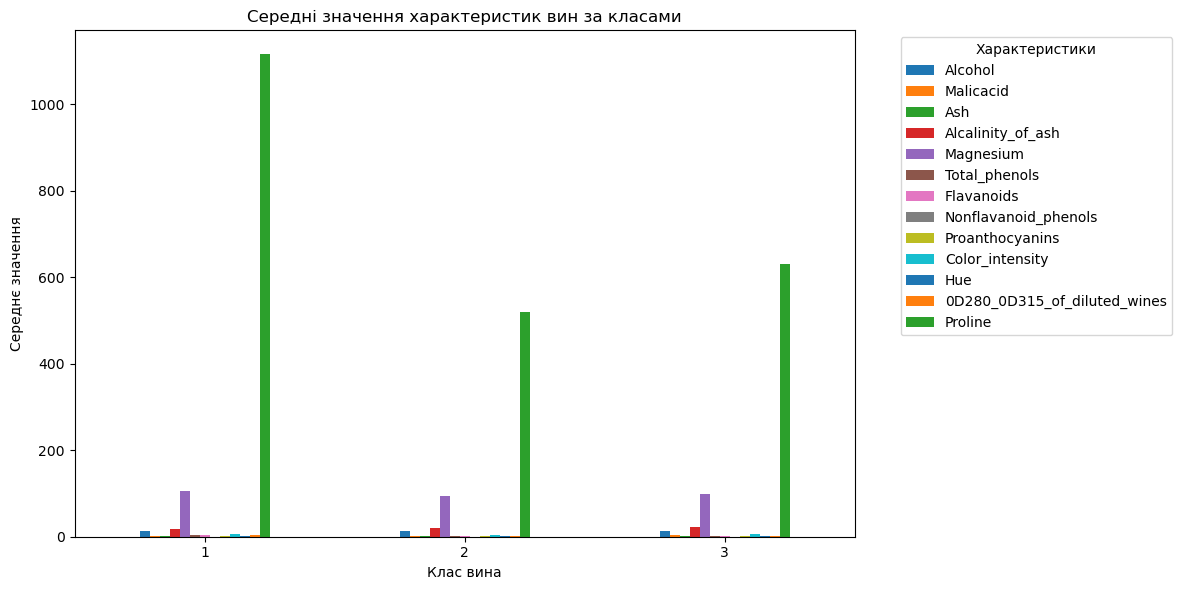

In [23]:
df = pd.DataFrame(X, columns=wine.data.feature_names)
df['class'] = y

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = pd.Categorical(df[col]).codes

print("Інформація про датасет після перетворення:")
df.info()

mean_values = df.groupby('class').mean()

mean_values.plot(kind='bar', figsize=(12, 6))

plt.title('Середні значення характеристик вин за класами')
plt.xlabel('Клас вина')
plt.ylabel('Середнє значення')
plt.xticks(rotation=0) 
plt.legend(title='Характеристики', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

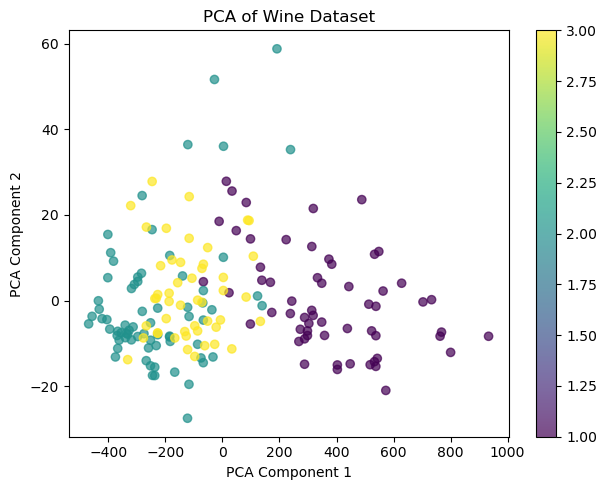

<Figure size 1000x600 with 0 Axes>

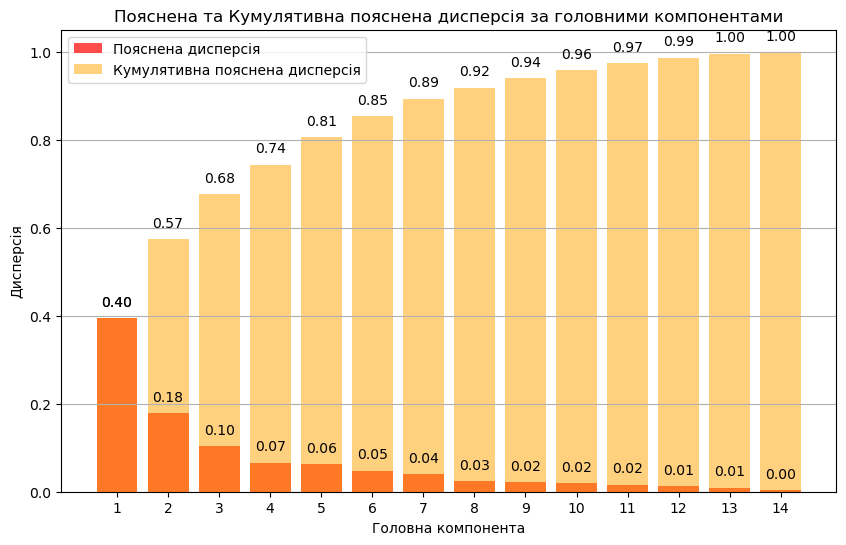

In [18]:

pca = PCA()
pca.fit(scaled_data)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('PCA of Wine Dataset')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))

plt.bar(range(1, len(explained_variance) + 1), explained_variance, color='red', alpha=0.7, label='Пояснена дисперсія')

plt.bar(range(1, len(cumulative_variance) + 1), cumulative_variance, color='orange', alpha=0.5, label='Кумулятивна пояснена дисперсія')

for i, v in enumerate(explained_variance):
    plt.text(i + 1, v + 0.02, f'{v:.2f}', ha='center', va='bottom')

for i, v in enumerate(cumulative_variance):
    plt.text(i + 1, v + 0.02, f'{v:.2f}', ha='center', va='bottom')

plt.title('Пояснена та Кумулятивна пояснена дисперсія за головними компонентами')
plt.xlabel('Головна компонента')
plt.ylabel('Дисперсія')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(axis='y')
plt.legend()
plt.show()



In [19]:
# PCA з 2 компонентами

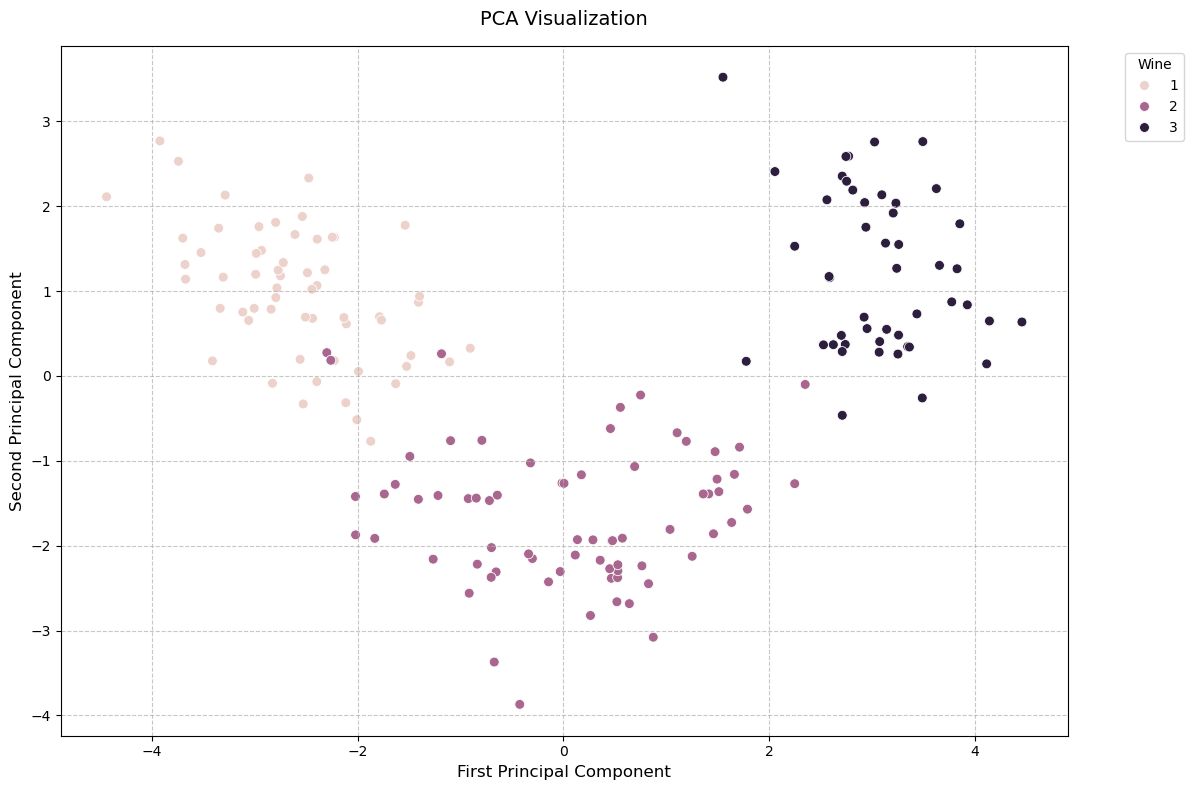

In [20]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_result_df = pd.DataFrame({'pca_1': pca_result[:,0], 'pca_2': pca_result[:,1], 'label': y})

plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_1', y='pca_2', 
                hue='label', 
                data=pca_result_df, 
                s=50, 
                alpha=1)  

plt.title('PCA Visualization', fontsize=14, pad=15)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)

plt.legend(title='Wine', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left',
          fontsize=10)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


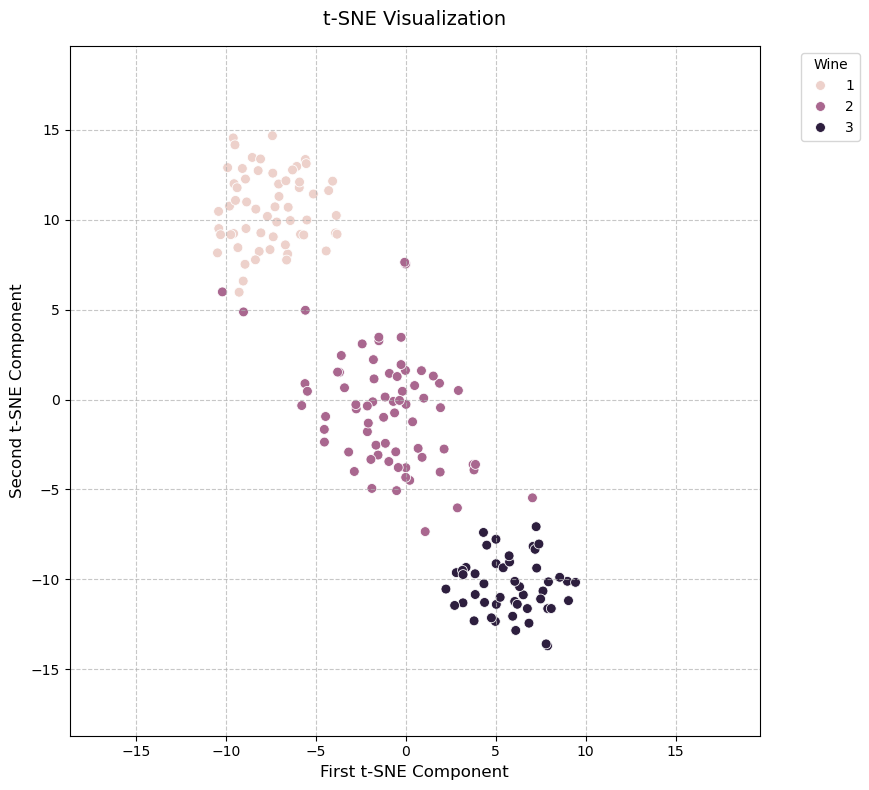

In [27]:

# Використання t-SNE для зменшення розмірності до 2D
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_data)

tsne_result_df = pd.DataFrame({
    'tsne_1': tsne_results[:,0], 
    'tsne_2': tsne_results[:,1], 
    'label': y
})
plt.figure(figsize=(12, 8))
sns.scatterplot(x='tsne_1', 
                y='tsne_2', 
                hue='label', 
                data=tsne_result_df,
                s=50, 
                alpha=1)  

plt.title('t-SNE Visualization', fontsize=14, pad=15)
plt.xlabel('First t-SNE Component', fontsize=12)
plt.ylabel('Second t-SNE Component', fontsize=12)

lim = (tsne_results.min()-5, tsne_results.max()+5)
plt.xlim(lim)
plt.ylim(lim)

plt.gca().set_aspect('equal')

plt.legend(title='Wine',
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          fontsize=10)

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()


In [28]:
#3Кластерний аналіз
#1) За допомогою алгоритму k-means зробіть квантування зображення (видалення візуально надлишкової інформації) 
#з глибиною 64, 32, 16 та 8 рівнів для будь-якого обраного самостійно зображення.

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from time import time
from PIL import Image

64 кольорів
0.063 секунд
32 кольорів
0.031 секунд
16 кольорів
0.023 секунд
8 кольорів
0.022 секунд


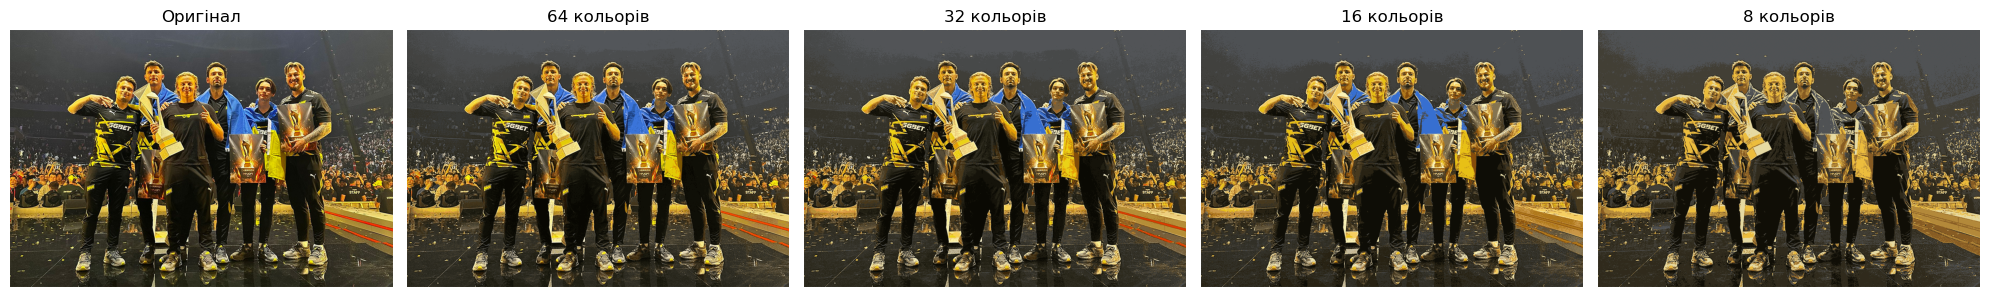

In [30]:
image = Image.open("navi.jpeg")
image_array = np.array(image, dtype=np.float64) / 255

w, h, d = original_shape = tuple(image_array.shape)
assert d == 3
image_array_2d = np.reshape(image_array, (w * h, d))

def quantize_image(n_colors):
    print(f"{n_colors} кольорів")
    t0 = time()
    
    image_array_sample = shuffle(image_array_2d, random_state=0, n_samples=1000)
    
    kmeans = KMeans(n_clusters=n_colors, random_state=0).fit(image_array_sample)
    
    labels = kmeans.predict(image_array_2d)
    
    print(f"{time() - t0:.3f} секунд")
    
    quantized_image = kmeans.cluster_centers_[labels].reshape(w, h, d)
    
    return quantized_image

n_colors_list = [64, 32, 16, 8]
quantized_images = [quantize_image(n) for n in n_colors_list]

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(image_array)
plt.title("Оригінал")
plt.axis('off')

for i, (n_colors, quantized_image) in enumerate(zip(n_colors_list, quantized_images), start=2):
    plt.subplot(1, 5, i)
    plt.imshow(quantized_image)
    plt.title(f"{n_colors} кольорів")
    plt.axis('off')

plt.tight_layout()
plt.show()

64 кольорів
0.035 секунд
32 кольорів
0.017 секунд
16 кольорів
0.010 секунд
8 кольорів
0.007 секунд


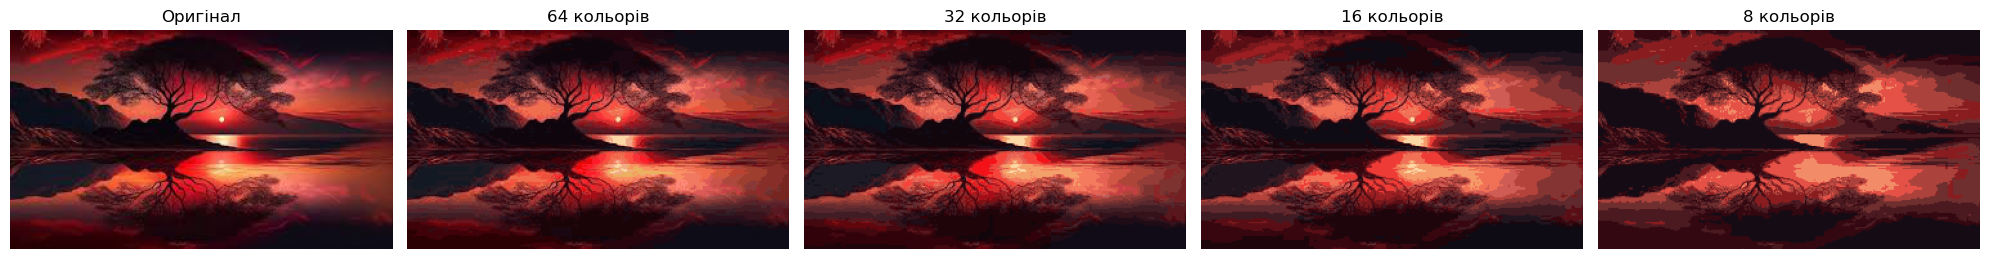

In [31]:
image = Image.open("nature.jpeg")
image_array = np.array(image, dtype=np.float64) / 255

w, h, d = original_shape = tuple(image_array.shape)
assert d == 3
image_array_2d = np.reshape(image_array, (w * h, d))

def quantize_image(n_colors):
    print(f"{n_colors} кольорів")
    t0 = time()
    
    image_array_sample = shuffle(image_array_2d, random_state=0, n_samples=1000)
    
    kmeans = KMeans(n_clusters=n_colors, random_state=0).fit(image_array_sample)
    
    labels = kmeans.predict(image_array_2d)
    
    print(f"{time() - t0:.3f} секунд")
    
    quantized_image = kmeans.cluster_centers_[labels].reshape(w, h, d)
    
    return quantized_image

n_colors_list = [64, 32, 16, 8]
quantized_images = [quantize_image(n) for n in n_colors_list]

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(image_array)
plt.title("Оригінал")
plt.axis('off')

for i, (n_colors, quantized_image) in enumerate(zip(n_colors_list, quantized_images), start=2):
    plt.subplot(1, 5, i)
    plt.imshow(quantized_image)
    plt.title(f"{n_colors} кольорів")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
#Завантажте набір текстових даних (з мітками класів). Проведіть передобробку даних (видаліть стоп-слова, пунктуацію),
#за допомогою wordcloud зробіть візуалізацію найбільш поширених слів або n-gram у кожному класі. Векторизуйте тексти
#(наприклад за допомогою sklearn.feature_extraction.text.TfidfVectorizer). Проведіть класифікацію текстових даних, зробіть оцінку якості. 

In [33]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud




In [34]:
df = pd.read_csv("reviews.csv")
df.shape


(10000, 8)

In [35]:
df.columns


Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514'],
      dtype='object')

In [36]:

Counter( df['Rating'])

Counter({'5': 3832,
         '4': 2373,
         '1': 1735,
         '3': 1193,
         '2': 684,
         '4.5': 69,
         '3.5': 47,
         nan: 38,
         '2.5': 19,
         '1.5': 9,
         'Like': 1})

In [37]:
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)
    text = text.lower()
    
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['Cleaned'] = df['Review'].apply(clean)

df = df[df['Cleaned'] != ""]

print(df['Cleaned'].head())
print(f"Рядків після філіьтрації --->{len(df)}")

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    must try great food great ambience thnx servic...
3    soumen das arun great guy behavior sincerety g...
4    food goodwe ordered kodi drumsticks basket mut...
Name: Cleaned, dtype: object
Рядків після філіьтрації --->9931


In [38]:
rating_map = {
    '4.5': '5',
    '3.5': '4',
    '2.5': '3',
    '1.5': '2'
}

# я вирішив видалити строку з значенням Like а також рейтинги типу 4,5 привести до вигляду 5, а 3,5 до 4 і тдю
df = df[df['Rating'] != 'Like']

df['Rating'] = df['Rating'].astype(str).replace(rating_map).astype(float)

from collections import Counter
Counter( df['Rating'])

Counter({5.0: 3880, 4.0: 2418, 1.0: 1731, 3.0: 1209, 2.0: 692})

In [39]:
df.columns


Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514', 'Cleaned'],
      dtype='object')

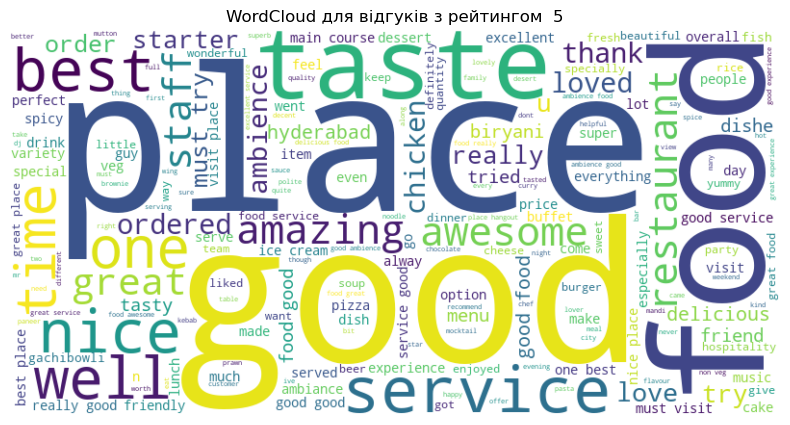

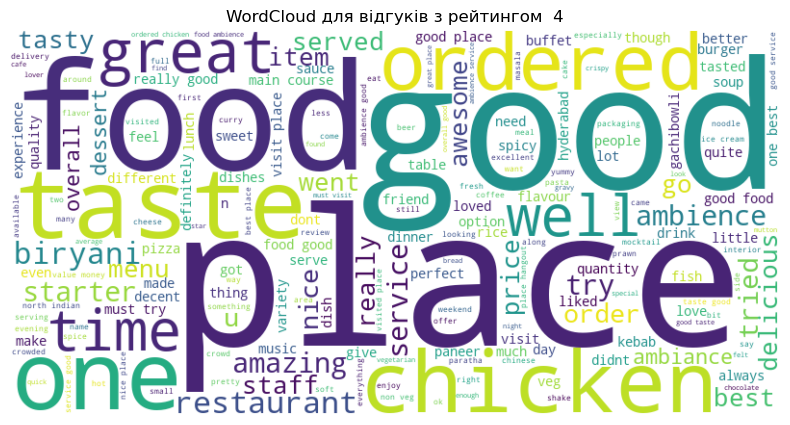

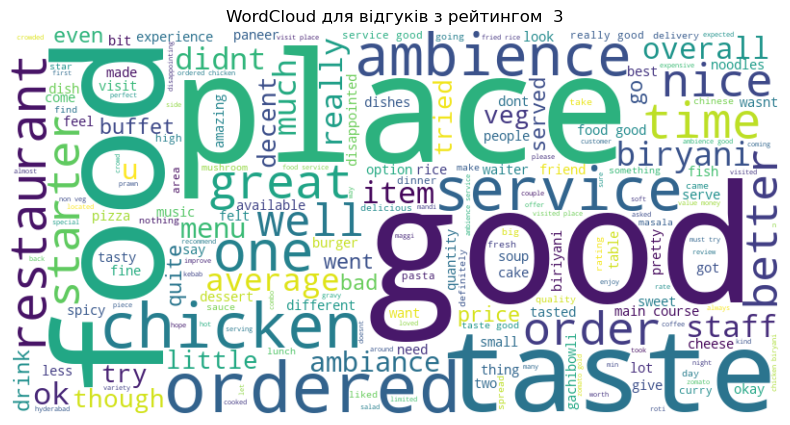

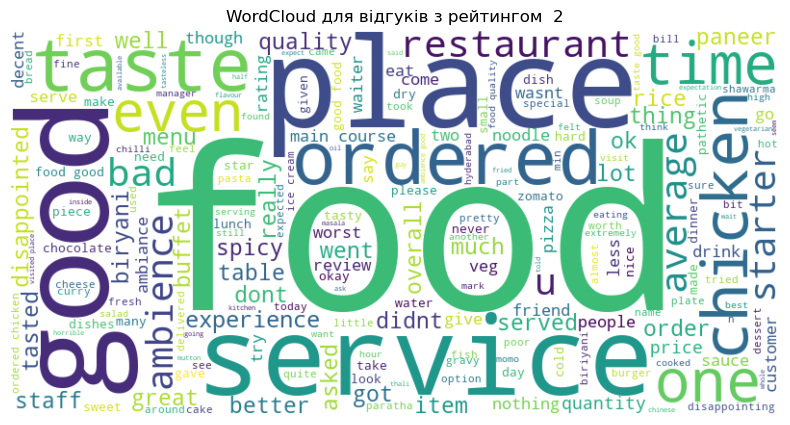

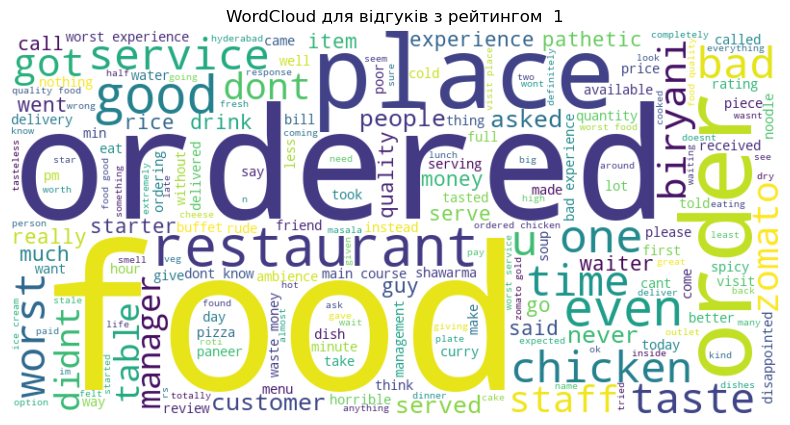

In [40]:

def visualize(label):
    text = ' '.join(df[df['Rating'] == label]['Cleaned'])
    
    word_freq = Counter(text.split())
    
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud для відгуків з рейтингом  {label}')
    plt.show()


for sentiment in [5, 4, 3, 2, 1]:
    visualize(sentiment)

In [42]:
# векторизація
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Cleaned'])
y = df['Rating']

# поділ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# навчання 
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Звіт і матриця невідповідності:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Звіт і матриця невідповідності:
[[253   6  10  37  12]
 [ 59   3  20  43  12]
 [ 27   1  25 157  34]
 [ 14   0  12 287 172]
 [ 12   0   4 143 643]]
              precision    recall  f1-score   support

         1.0       0.69      0.80      0.74       318
         2.0       0.30      0.02      0.04       137
         3.0       0.35      0.10      0.16       244
         4.0       0.43      0.59      0.50       485
         5.0       0.74      0.80      0.77       802

    accuracy                           0.61      1986
   macro avg       0.50      0.46      0.44      1986
weighted avg       0.58      0.61      0.57      1986

